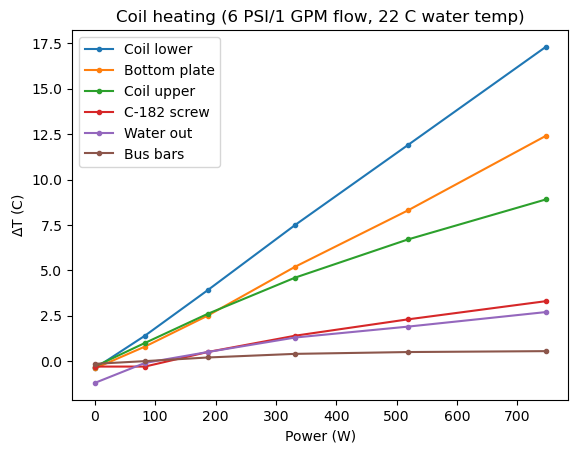

In [1]:
import numpy as np
import matplotlib.pyplot as plt

data = np.array(
    [[0, 	21.1,	19.9,	20.7,	20.7,	20.8,	20.8,	21.0,	20.9],
    [100,  	21.5,	21.4,	22.3,	22.9,	22.5,	21.2,	21.7,	21.3],
    [150,  	21.8,	22.3,	24.3,	25.7,	24.4,	22.3,	22.1,	21.9],
    [200,  	22.6,	23.9,	27.8,	30.1,	27.2,	24.0,	23.0,	23.0],
    [250,  	23.4,	25.3,	31.7,	35.3,	30.1,	25.7,	23.8,	24.0],
    [300,  	22.8,	25.5,	35.2,	40.1,	31.7,	26.1,	23.3,	23.4]])

currents = data[:,0]
powers = 0.0083*currents**2 # convert current to units of power
watertemps = data[:,1] # get input water temps
deltaT = data[:, 2:] - watertemps[:,None] # convert to delta T

deltaT[:, 5] = np.mean(deltaT[:, 5:], axis=1) # average bus bars together
deltaT = deltaT[:, :6] # only keep 6 columns of data

labels = ['Water out',	'Bottom plate',	'Coil lower',	'Coil upper',
          'C-182 screw', 'Bus bars']

inds = np.argsort(deltaT[-1,:])[::-1] # get indices to sort by delta T 
deltaT = deltaT[:,inds] # sort data by inds
labels = np.array(labels) # get labels for sorted data
labels = labels[inds] # sort labels by inds 

for i in range(6):
    plt.plot(powers,deltaT[:,i],'.-', label=labels[i])

plt.title('Coil heating (6 PSI/1 GPM flow, 22 C water temp)')
plt.legend()
plt.xlabel('Power (W)')
plt.ylabel(r'$\Delta$T (C)')
plt.show()

[  0. 100. 150. 200. 250. 300. 350.]
['Water in' 'Water out' 'Brass disc outside' 'Lower coil outside'
 'Middle coil outside' 'Upper coil outside' 'Lower coil inside'
 'Upper coil inside']
[[20.8 20.9 20.5 20.7 20.8 20.7 20.9 20.8]
 [20.9 21.2 21.1 21.3 21.6 21.3 21.3 21.5]
 [21.9 22.4 22.7 23 23.6 22.8 22.7 23.2]
 [22.6 23.5 24 24.5 25.6 24.2 24.1 25]
 [22.3 23.8 25 25.3 26.9 25.1 24.9 26.2]
 [22.4 24.5 26 26.7 28.9 26.2 26 27.8]
 [22.6 25.5 27.3 28.4 31.4 27.9 27.5 29.9]]
(7, 8)


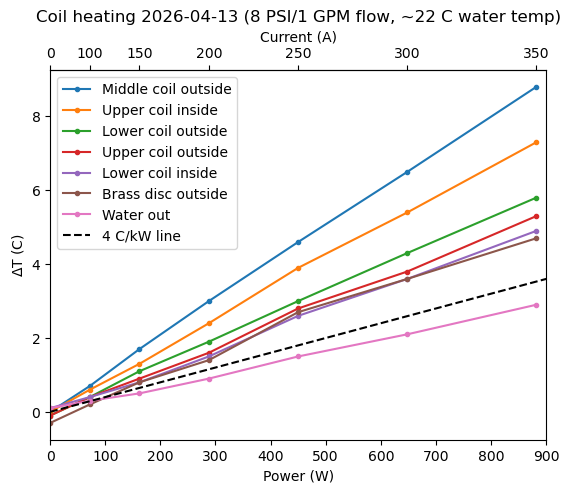

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# load data from UnifiedBitterCoilData.xlsx, sheet "Thermal 4_13_26"
data = pd.read_excel('UnifiedBitterCoilData.xlsx', sheet_name='Thermal 4_13_26', header=None).values
resistance = 0.0072 # resistance of coil in ohms

currents = data[1:-2, 0]
currents = np.array([float(x[:-1]) for x in currents]) # convert to float
names = data[0, 1:]
temps = data[1:-2, 1:]
# show data for debug 
print(currents)
print(names)
print(temps)
print(temps.shape)

powers = resistance*currents**2 # convert current to units of power
deltaT = temps[:, 1:] - temps[:, :1] # convert to delta T
labels = names[1:] # get labels for delta T data

inds = np.argsort(deltaT[-1,:])[::-1] # get indices to sort by delta T 
deltaT = deltaT[:,inds] # sort data by inds
labels = np.array(labels) # get labels for sorted data
labels = labels[inds] # sort labels by inds 

for i in range(7):
    plt.plot(powers,deltaT[:,i],'.-', label=labels[i])

plt.plot([0, 900], [0, 900*4/1000], 'k--', label='4 C/kW line') # add line for 4 C/kW
plt.title('Coil heating 2026-04-13 (8 PSI/1 GPM flow, ~22 C water temp)')
plt.legend()
plt.xlabel('Power (W)')
plt.ylabel(r'$\Delta$T (C)')
plt.xlim(0, 900)
ax = plt.gca()
topax = ax.secondary_xaxis('top', functions=(lambda x: np.sqrt(x/resistance), lambda x: x**2*resistance))
topax.set_xlabel('Current (A)')
topax.set_xticks(currents)
plt.show()

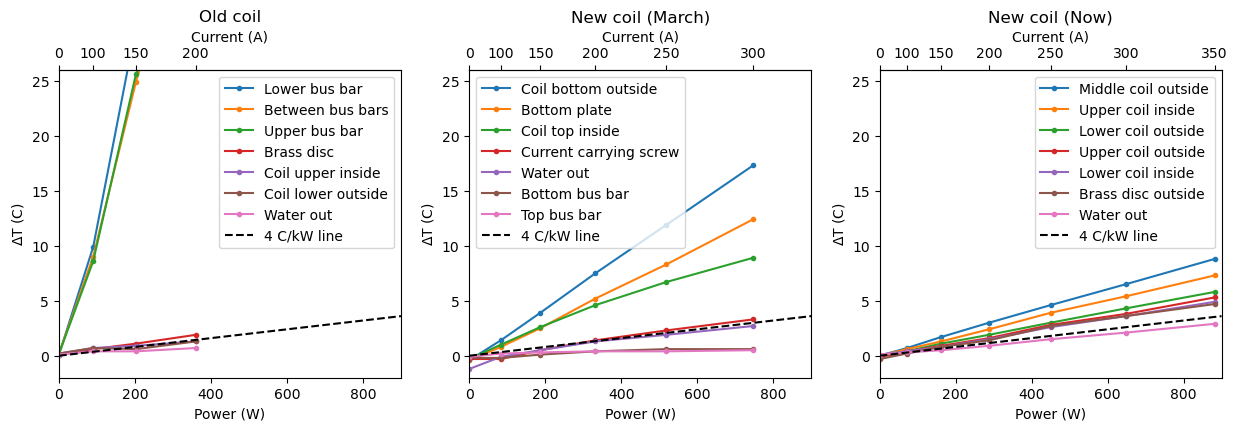

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


sheetnames = ['Thermal 3_18_26', 'Thermal 3_05_26', 'Thermal 4_13_26']
displaynames = ['Old coil', 'New coil (March)', 'New coil (Now)']
resistances = [0.009, 0.0083, 0.0072] # resistances of coils in ohms

plt.figure(figsize=(15,4))

for i in range(3):

    resistance = resistances[i]
    displayname = displaynames[i]

    # load data from UnifiedBitterCoilData.xlsx
    data = pd.read_excel('UnifiedBitterCoilData.xlsx', sheet_name=sheetnames[i], header=None).values

    currents = data[1:-2, 0]
    currents = np.array([float(x[:-1]) for x in currents]) # convert to float
    names = data[0, 1:]
    temps = data[1:-2, 1:]
    # show data for debug 

    powers = resistance*currents**2 # convert current to units of power
    deltaT = temps[:, 1:] - temps[:, :1] # convert to delta T
    labels = names[1:] # get labels for delta T data

    inds = np.argsort(deltaT[-1,:])[::-1] # get indices to sort by delta T 
    deltaT = deltaT[:,inds] # sort data by inds
    labels = np.array(labels) # get labels for sorted data
    labels = labels[inds] # sort labels by inds 

    ax = plt.subplot(1,3, i+1)
    # plt.figure()
    for j in range(len(labels)):
        plt.plot(powers,deltaT[:,j],'.-', label=labels[j])
    plt.plot([0, 900], [0, 900*4/1000], 'k--', label='4 C/kW line') # add line for 4 C/kW
    plt.title(displayname)
    plt.legend()
    plt.xlabel('Power (W)')
    plt.ylabel(r'$\Delta$T (C)')
    plt.xlim(0, 900)
    plt.ylim(-2, 26)
    topax = ax.secondary_xaxis('top', functions=(lambda x, r=resistance: np.sqrt(x/r), 
                                                 lambda x, r=resistance: x**2*r))
    topax.set_xlabel('Current (A)')
    topax.set_xticks(currents)


# save figure as pdf
plt.savefig('coil_heating_comparison.pdf')

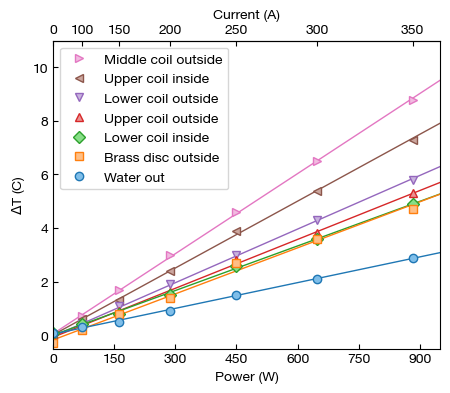

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Option A: Use a specific font name
plt.rcParams['font.family'] = 'Helvetica Neue'

sheetnames = ['Thermal 3_18_26', 'Thermal 3_05_26', 'Thermal 4_13_26']
displaynames = ['Old coil', 'New coil (March)', 'New coil (Now)']
resistances = [0.009, 0.0083, 0.0072] # resistances of coils in ohms


i = 2

resistance = resistances[i]
displayname = displaynames[i]

# load data from UnifiedBitterCoilData.xlsx
data = pd.read_excel('UnifiedBitterCoilData.xlsx', sheet_name=sheetnames[i], header=None).values

currents = data[1:-2, 0]
currents = np.array([float(x[:-1]) for x in currents]) # convert to float
names = data[0, 1:]
temps = np.asarray(data[1:-2, 1:], dtype=np.float64) # convert to numpy array of floats
# show data for debug 
# print(f"dtype of temps: {temps.dtype}")

powers = resistance*currents**2 # convert current to units of power
deltaT = temps[:, 1:] - temps[:, :1] # convert to delta T
labels = names[1:] # get labels for delta T data

# print(f"deltaT: {deltaT}")

inds = np.argsort(deltaT[-1,:])[::-1] # get indices to sort by delta T 
deltaT = deltaT[:,inds] # sort data by inds
labels = np.array(labels) # get labels for sorted data
labels = labels[inds] # sort labels by inds 

# print(f"dtype of deltaT: {deltaT.dtype}")
# print(f"dtype of powers: {powers.dtype}")

# helper function to lighten colors
def lighten_color(color, amount=0.5):
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])

plt.figure(figsize=(5,4))
colors = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6']
markers = ['o', 's', 'D', '^', 'v', '<', '>']
# invert order of colors and markers so that the most important data set (bus bars) is plotted on top
colors = colors[::-1]
markers = markers[::-1]

for j in range(len(labels)):
    # plot linear regression line for each data set
    coeffs = np.polyfit(powers, deltaT[:,j], 1)
    x = np.linspace(0, 1000, 100)
    y = coeffs[0]*x + coeffs[1]
    plt.plot(x, y, color=colors[j], linestyle='-', linewidth=1)

for j in range(len(labels)):
    plt.plot(powers,deltaT[:,j],markers[j], color=colors[j], 
             markerfacecolor=lighten_color(colors[j], 0.5),
             linewidth=1, label=labels[j])

# plt.title(displayname)
plt.legend(loc='upper left')
plt.xlabel('Power (W)')
plt.ylabel(r'$\Delta$T (C)')
plt.xlim(0, 950)
plt.ylim(-0.5,11)
plt.xticks(np.arange(0, 901, 150))
ax = plt.gca()
topax = ax.secondary_xaxis('top', functions=(lambda x, r=resistance: np.sqrt(x/r), 
                                                lambda x, r=resistance: x**2*r))
topax.set_xlabel('Current (A)')
topax.set_xticks(currents)
topax.tick_params(axis='x', direction='in')

plt.tick_params(axis='both', direction='in')
# save figure as pdf
plt.savefig('/Users/henry/Desktop/tempfig.pdf')


currents = [  0. 100. 150. 200. 250. 300. 350.]
names = ['Water in' 'Water out' 'Screw top' 'Bus bar' 'CuCr disc' 'Lower outside'
 'Upper outside' 'Middle inside']
dtype of temps: float64
temps = [[21.7 21.8 21.6 21.5 21.6 21.6 21.6 21.7]
 [21.5 22.1 22.1 22.  22.4 22.7 22.3 22.6]
 [21.6 22.5 22.6 22.3 23.  23.4 23.1 23.4]
 [22.6 23.7 23.6 23.2 24.3 25.  24.5 25.2]
 [22.2 24.  24.2 22.7 25.  25.8 24.9 25.7]
 [22.3 24.7 24.7 22.9 25.9 27.3 26.  27.2]
 [22.5 25.5 24.9 23.2 27.  28.8 27.3 28.9]]
inds = [6 4 5 3 1 2]


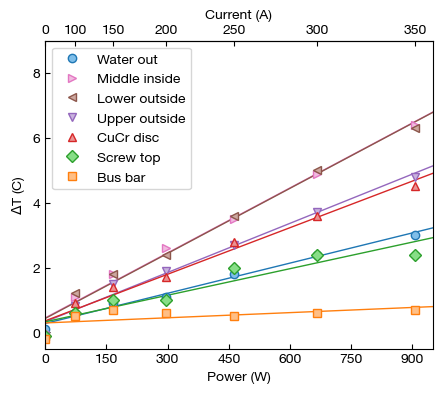

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Option A: Use a specific font name
plt.rcParams['font.family'] = 'Helvetica Neue'

sheetnames = ['Thermal 3_18_26', 'Thermal 3_05_26', 'Thermal 4_13_26', 'C1 Thermal 6_10_26']
displaynames = ['Old coil', 'New coil (March)', 'New coil (Now)', 'C1 coil (Now)']
resistances = [0.009, 0.0083, 0.0072, 0.0074] # resistances of coils in ohms


i = 3

resistance = resistances[i]
displayname = displaynames[i]

# load data from UnifiedBitterCoilData.xlsx
data = pd.read_excel('UnifiedBitterCoilData.xlsx', sheet_name=sheetnames[i], header=None).values
# print(data)

currents = data[1:-2, 0]
currents = np.array([float(x[:-1]) for x in currents]) # convert to float
print(f"currents = {currents}")
names = data[0, 1:]
print(f"names = {names}")
temps = np.asarray(data[1:-2, 1:], dtype=np.float64) # convert to numpy array of floats
# show data for debug 
print(f"dtype of temps: {temps.dtype}")
print(f"temps = {temps}")

powers = resistance*currents**2 # convert current to units of power
deltaT = temps[:, 1:] - temps[:, :1] # convert to delta T
labels = names[1:] # get labels for delta T data

# print(f"deltaT: {deltaT}")

inds = 1+np.argsort(deltaT[-1,1:])[::-1] # get indices to sort by delta T 
print(f"inds = {inds}")

deltaT[:,1:] = deltaT[:,inds] # sort data by inds
labels = np.array(labels) # get labels for sorted data
labels[1:] = labels[inds] # sort labels by inds 


# print(f"dtype of deltaT: {deltaT.dtype}")
# print(f"dtype of powers: {powers.dtype}")

# helper function to lighten colors
def lighten_color(color, amount=0.5):
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])

plt.figure(figsize=(5,4))
colors = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C0']
markers = ['s', 'D', '^', 'v', '<', '>', 'o']
# invert order of colors and markers so that the most important data set (bus bars) is plotted on top
colors = colors[::-1]
markers = markers[::-1]

for j in range(len(labels)):
    # plot linear regression line for each data set
    coeffs = np.polyfit(powers, deltaT[:,j], 1)
    x = np.linspace(0, 1000, 100)
    y = coeffs[0]*x + coeffs[1]
    plt.plot(x, y, color=colors[j], linestyle='-', linewidth=1)

for j in range(len(labels)):
    plt.plot(powers,deltaT[:,j],markers[j], color=colors[j], 
             markerfacecolor=lighten_color(colors[j], 0.5),
             linewidth=1, label=labels[j])

# plt.title(displayname)
plt.legend(loc='upper left')
plt.xlabel('Power (W)')
plt.ylabel(r'$\Delta$T (C)')
plt.xlim(0, 950)
plt.ylim(-0.5,9)

plt.xticks(np.arange(0, 901, 150))
ax = plt.gca()
topax = ax.secondary_xaxis('top', functions=(lambda x, r=resistance: np.sqrt(x/r), 
                                                lambda x, r=resistance: x**2*r))
topax.set_xlabel('Current (A)')
topax.set_xticks(currents)
topax.tick_params(axis='x', direction='in')

plt.tick_params(axis='both', direction='in')
# save figure as pdf
plt.savefig('/Users/henry/Desktop/tempfig.pdf')